In [7]:
import pandas as pd
PATH = R"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\imagenes"
df = pd.read_csv(r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\df_subset_500.csv')

# Seleccionar una imagen al azar
muestra = df.sample(1).iloc[0]
print(muestra['full_path'])

files/p12/p12594793/s54328670/5a3fa739-807e5667-fd54fbfb-1df52e6a-5acd167c.jpg


In [ ]:
C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\imagenes\files\p10\p10827966\s53227432\3dfcc853-fc720341-dbf5e979-8df748e5-e7ae7d07.jpg

In [4]:
import torchxrayvision as xrv
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

C:\Users\trodr\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


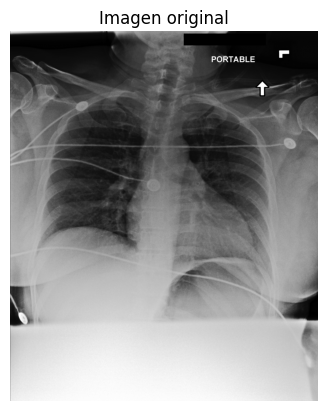

In [15]:
ruta = r"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\imagenes\files/p12/p12594793/s54328670/5a3fa739-807e5667-fd54fbfb-1df52e6a-5acd167c.jpg"

img_pil = Image.open(ruta).convert("L")  # escala de grises
img_np = np.array(img_pil)

plt.imshow(img_np, cmap="gray")
plt.title("Imagen original")
plt.axis("off")
plt.show()

In [16]:
# Cargar modelo de segmentación preentrenado
seg_model = xrv.baseline_models.chestx_det.PSPNet()
seg_model.eval()

print("Estructuras que segmenta:", seg_model.targets)

Estructuras que segmenta: ['Left Clavicle', 'Right Clavicle', 'Left Scapula', 'Right Scapula', 'Left Lung', 'Right Lung', 'Left Hilus Pulmonis', 'Right Hilus Pulmonis', 'Heart', 'Aorta', 'Facies Diaphragmatica', 'Mediastinum', 'Weasand', 'Spine']


In [18]:
print("Shape img_np:", img_np.shape)
print("Shape img_tensor:", img_tensor.shape)

Shape img_np: (3050, 2539)
Shape img_tensor: torch.Size([1, 3050, 2539])


In [19]:
import torchvision.transforms as T

# Normalizar
img_tensor = xrv.datasets.normalize(img_np, maxval=255, reshape=True)
img_tensor = torch.from_numpy(img_tensor).float()

print("Shape después de normalize:", img_tensor.shape)

# Agregar dimensión de batch → [1, 1, H, W]
if img_tensor.dim() == 3:
    img_tensor = img_tensor.unsqueeze(0)

# Center crop para hacerla cuadrada
lado = min(img_tensor.shape[2], img_tensor.shape[3])
center_crop = T.CenterCrop(lado)
img_tensor = center_crop(img_tensor)

print("Shape final:", img_tensor.shape)

Shape después de normalize: torch.Size([1, 3050, 2539])
Shape final: torch.Size([1, 1, 2539, 2539])


In [20]:
with torch.no_grad():
    output = seg_model(img_tensor)

print("Shape output:", output.shape)
print("Targets disponibles:", seg_model.targets)

Shape output: torch.Size([1, 14, 512, 512])
Targets disponibles: ['Left Clavicle', 'Right Clavicle', 'Left Scapula', 'Right Scapula', 'Left Lung', 'Right Lung', 'Left Hilus Pulmonis', 'Right Hilus Pulmonis', 'Heart', 'Aorta', 'Facies Diaphragmatica', 'Mediastinum', 'Weasand', 'Spine']


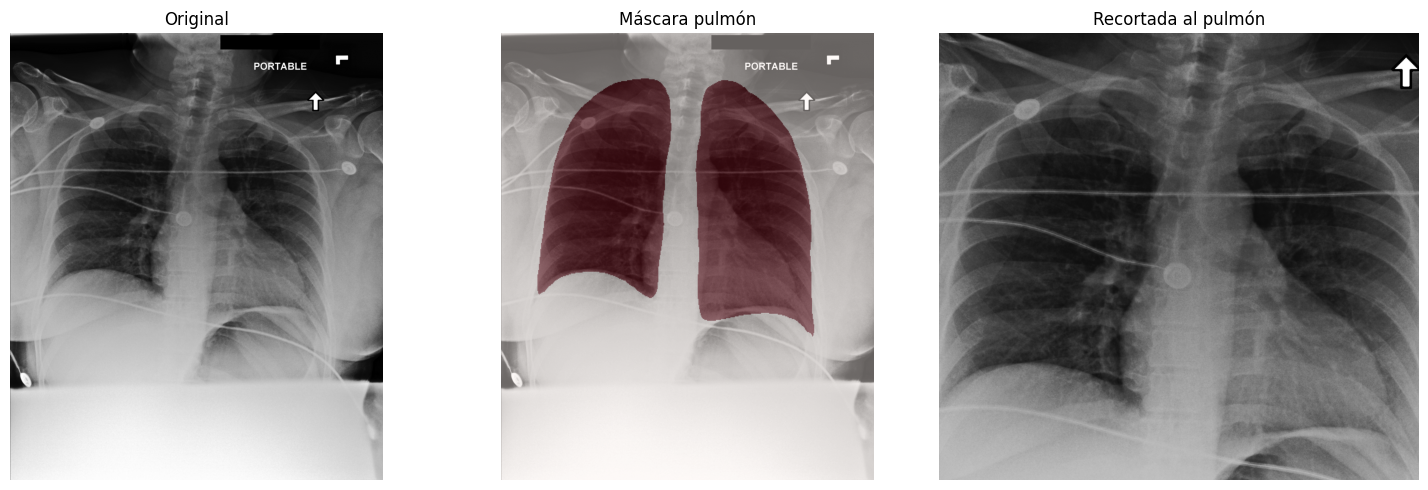

In [21]:
# Extraer máscaras de pulmón izquierdo y derecho
idx_left  = seg_model.targets.index('Left Lung')
idx_right = seg_model.targets.index('Right Lung')

mask_left  = output[0, idx_left].numpy()
mask_right = output[0, idx_right].numpy()

# Combinar ambas máscaras
mask_lung = np.maximum(mask_left, mask_right)
mask_binaria = (mask_lung > 0.5).astype(np.uint8)

# Redimensionar máscara al tamaño de la imagen original
from PIL import Image as PILImage
mask_pil = PILImage.fromarray((mask_binaria * 255).astype(np.uint8))
mask_resized = np.array(mask_pil.resize((img_np.shape[1], img_np.shape[0]), PILImage.NEAREST)) // 255

# Bounding box del pulmón
filas = np.any(mask_resized, axis=1)
cols  = np.any(mask_resized, axis=0)
y1, y2 = np.where(filas)[0][[0, -1]]
x1, x2 = np.where(cols)[0][[0, -1]]

# Recortar imagen original al bounding box
img_crop = img_np[y1:y2, x1:x2]

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_np, cmap='gray')
axes[1].imshow(mask_resized, alpha=0.4, cmap='Reds')
axes[1].set_title('Máscara pulmón')
axes[1].axis('off')

axes[2].imshow(img_crop, cmap='gray')
axes[2].set_title('Recortada al pulmón')
axes[2].axis('off')

plt.tight_layout()
plt.show()

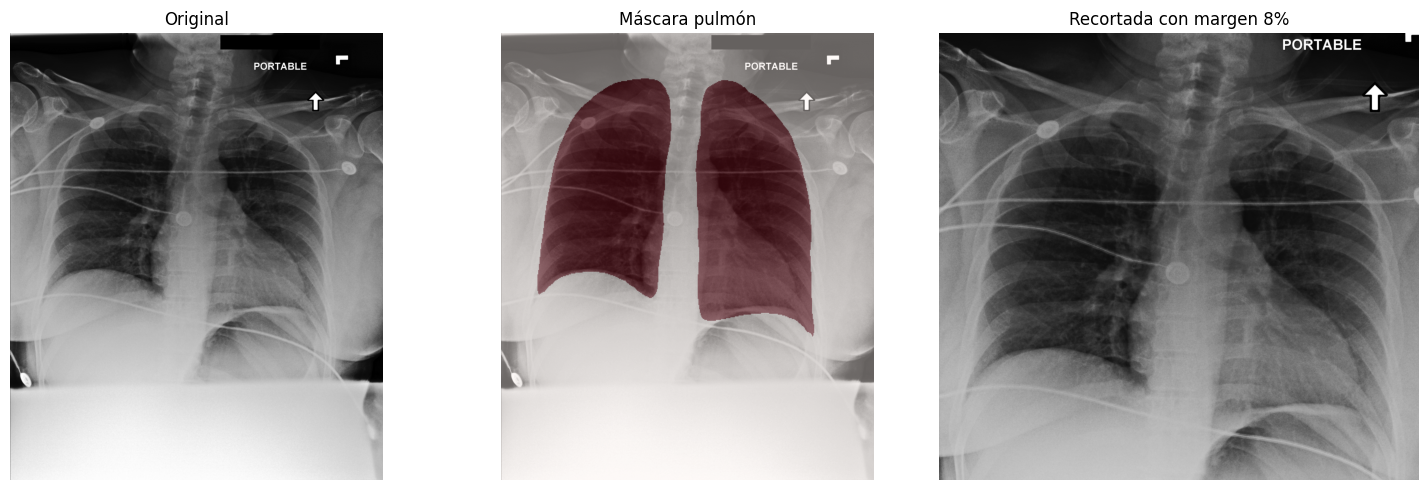

Original: (3050, 2539) → Recortada: (2036, 2183)


In [22]:
# Extraer máscaras de pulmón izquierdo y derecho
idx_left  = seg_model.targets.index('Left Lung')
idx_right = seg_model.targets.index('Right Lung')

mask_left  = output[0, idx_left].numpy()
mask_right = output[0, idx_right].numpy()

# Combinar ambas máscaras
mask_lung = np.maximum(mask_left, mask_right)
mask_binaria = (mask_lung > 0.5).astype(np.uint8)

# Redimensionar máscara al tamaño de la imagen original
from PIL import Image as PILImage
mask_pil = PILImage.fromarray((mask_binaria * 255).astype(np.uint8))
mask_resized = np.array(mask_pil.resize((img_np.shape[1], img_np.shape[0]), PILImage.NEAREST)) // 255

# Bounding box con margen del 8%
filas = np.any(mask_resized, axis=1)
cols  = np.any(mask_resized, axis=0)
y1, y2 = np.where(filas)[0][[0, -1]]
x1, x2 = np.where(cols)[0][[0, -1]]

h, w = img_np.shape
margin_y = int((y2 - y1) * 0.08)
margin_x = int((x2 - x1) * 0.08)

y1 = max(0, y1 - margin_y)
y2 = min(h, y2 + margin_y)
x1 = max(0, x1 - margin_x)
x2 = min(w, x2 + margin_x)

# Recortar
img_crop = img_np[y1:y2, x1:x2]

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_np, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_np, cmap='gray')
axes[1].imshow(mask_resized, alpha=0.4, cmap='Reds')
axes[1].set_title('Máscara pulmón')
axes[1].axis('off')

axes[2].imshow(img_crop, cmap='gray')
axes[2].set_title('Recortada con margen 8%')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Original: {img_np.shape} → Recortada: {img_crop.shape}")

In [23]:
import pandas as pd

df = pd.read_csv(r'C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge\df_subset_500.csv')
print(df.shape)
print(df.columns.tolist())
print(df['full_path'].iloc[0])

(530, 20)
['dicom_id', 'subject_id', 'study_id', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices', 'full_path', 'ViewPosition', 'calidad-imagen']
files/p10/p10516278/s53994171/1621b732-f77b9463-87769d53-3175e5ed-1822d35f.jpg
